--- 1. Carregando Dataset ---
Arquivo carregado! Total de linhas: 300
Linhas após limpeza: 300
Distribuição da classe (contagem):
Não misógina    181
É Misógina      119
Name: count, dtype: int64

--- 2. Repeated Stratified K-Fold CV (5-fold, 3 repetições) ---
Fold 01 | Acurácia: 0.7000
Fold 02 | Acurácia: 0.7833
Fold 03 | Acurácia: 0.6833
Fold 04 | Acurácia: 0.7167
Fold 05 | Acurácia: 0.7000
Fold 06 | Acurácia: 0.7167
Fold 07 | Acurácia: 0.6167
Fold 08 | Acurácia: 0.7167
Fold 09 | Acurácia: 0.7000
Fold 10 | Acurácia: 0.7500
Fold 11 | Acurácia: 0.7167
Fold 12 | Acurácia: 0.7667
Fold 13 | Acurácia: 0.6000
Fold 14 | Acurácia: 0.6333
Fold 15 | Acurácia: 0.6500

--- 3. Resultados Agregados ---
Acurácia média: 0.6967
Desvio padrão:  0.0528
Mín/Máx:       0.6000 / 0.7833

Relatório de classificação (agregado em todos os folds):
              precision    recall  f1-score   support

Não misógina       0.70      0.86      0.77       543
  É Misógina       0.68      0.45      0.54       357

  

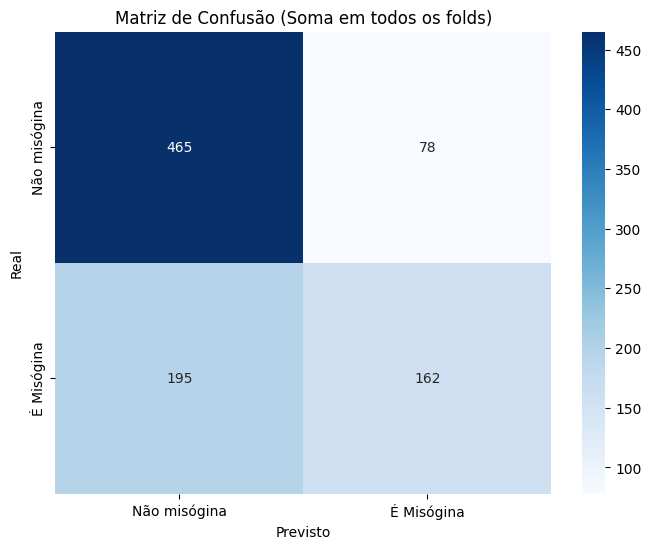

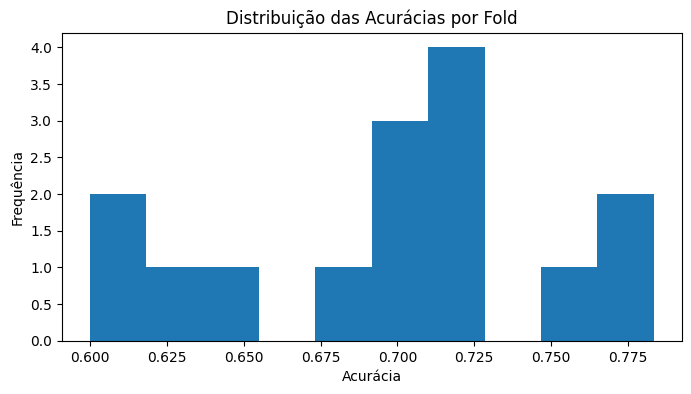

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# --- CONFIGURAÇÃO INICIAL (EDITAR AQUI) ---
ARQUIVO_CSV = 'tabela_final_pre_processada_spacy.csv'
NOME_COLUNA_ALVO = 'classificação'
COLUNA_TEXTO_ORIGEM = 'Tweets_Processados'  # onde está o texto (possivelmente como lista em string)

# CV: k-fold repetido
N_SPLITS = 5        # k
N_REPEATS = 3       # repetições
RANDOM_STATE = 42

# TF-IDF
MAX_FEATURES = 5000
MIN_DF = 2

# --- 1. Carregamento e Preparação ---
print("--- 1. Carregando Dataset ---")
df = pd.read_csv(ARQUIVO_CSV)
print(f"Arquivo carregado! Total de linhas: {len(df)}")

# Remover linhas nulas que podem ter surgido após limpeza
df.dropna(subset=[COLUNA_TEXTO_ORIGEM, NOME_COLUNA_ALVO], inplace=True)

# Função para garantir que o texto esteja pronto para o TF-IDF
# O CSV salva listas como strings "['a', 'b']", transformamos em "a b"
def limpar_formato_lista(texto):
    if isinstance(texto, str) and texto.startswith('[') and texto.endswith(']'):
        texto = texto.replace('[', '').replace(']', '').replace("'", "").replace('"', '')
        texto = texto.replace(',', ' ')
    return texto

df['Texto_Final'] = df[COLUNA_TEXTO_ORIGEM].apply(limpar_formato_lista)

# --- 2. Verificação da Coluna Alvo ---
if NOME_COLUNA_ALVO not in df.columns:
    raise ValueError(
        f"A coluna '{NOME_COLUNA_ALVO}' não existe. "
        f"Colunas disponíveis: {df.columns.tolist()}"
    )

X_text = df['Texto_Final'].astype(str).values
y = df[NOME_COLUNA_ALVO].values

print(f"Linhas após limpeza: {len(df)}")
print("Distribuição da classe (contagem):")
print(pd.Series(y).value_counts())

# --- 3. Pipeline (TF-IDF + Modelo) ---
pipeline = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=MAX_FEATURES, min_df=MIN_DF)),
    ("clf", MultinomialNB())
])

# --- 4. Repeated Stratified K-Fold Cross-Validation ---
print(f"\n--- 2. Repeated Stratified K-Fold CV ({N_SPLITS}-fold, {N_REPEATS} repetições) ---")
rskf = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE
)

accs = []
cms = []
y_true_all = []
y_pred_all = []

classes = np.unique(y)
classes_sorted = sorted(classes)  # para consistência na matriz

fold_id = 0
for train_idx, test_idx in rskf.split(X_text, y):
    fold_id += 1
    X_train, X_test = X_text[train_idx], X_text[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accs.append(acc)

    cm = confusion_matrix(y_test, y_pred, labels=classes_sorted)
    cms.append(cm)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

    print(f"Fold {fold_id:02d} | Acurácia: {acc:.4f}")

accs = np.array(accs)
cm_sum = np.sum(cms, axis=0)

print("\n--- 3. Resultados Agregados ---")
print(f"Acurácia média: {accs.mean():.4f}")
print(f"Desvio padrão:  {accs.std(ddof=1):.4f}")
print(f"Mín/Máx:       {accs.min():.4f} / {accs.max():.4f}")

print("\nRelatório de classificação (agregado em todos os folds):")
print(classification_report(y_true_all, y_pred_all))

# --- 5. Matriz de Confusão Agregada ---
plt.figure(figsize=(8, 6))
sns.heatmap(cm_sum, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes_sorted, yticklabels=classes_sorted)
plt.title('Matriz de Confusão (Soma em todos os folds)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# --- 6. Opcional: distribuição das acurácias ---
plt.figure(figsize=(8, 4))
plt.hist(accs, bins=10)
plt.title('Distribuição das Acurácias por Fold')
plt.xlabel('Acurácia')
plt.ylabel('Frequência')
plt.show()